In [ ]:

++ort pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from qpsolvers import solve_qp
from scipy.linalg import block_diag

# (a) Get data and compute log returns
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'TSLA']
start_date = '2020-03-13'
end_date = '2024-05-17' # yfinance includes start, excludes end, so go to 17th to include 16th

# Download historical data
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

# Compute log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# --- Helper Functions for Optimization and Metrics --- max(proportional, fixed)

def solve_markowitz(mu, Sigma, lambda_val, num_assets):
    """Solves the standard Markowitz problem using a QP solver."""
    P = 2 * lambda_val * Sigma
    q = -mu
    G = -np.eye(num_assets)
    h = np.zeros(num_assets)
    A = np.ones((1, num_assets))
    b = np.array([1.0])
    # Use a robust solver like osqp
    w_opt = solve_qp(P, q, G=G, h=h, A=A, b=b, solver='osqp')
    return w_opt if w_opt is not None else np.full(num_assets, 1.0/num_assets)

def solve_markowitz_tc(mu, Sigma, lambda_val, gamma, w_old, num_assets):
    """Solves the Markowitz problem with a transaction cost penalty."""
    # QP formulation for min λw'Σw - w'μ + γ||w - w_old||_1
    # Variables are x = [w, u_plus, u_minus] where |w-w_old| = u_plus + u_minus
    # Size of x is 3 * num_assets
    P = block_diag(2 * lambda_val * Sigma, np.zeros((2 * num_assets, 2 * num_assets)))
    q = np.hstack([-mu, gamma * np.ones(num_assets), gamma * np.ones(num_assets)])
    
    # Equality constraints: A_eq x = b_eq
    # 1. sum(w) = 1
    # 2. w - u_plus + u_minus = w_old
    A_eq = np.zeros((num_assets + 1, 3 * num_assets))
    A_eq[0, :num_assets] = 1.0
    A_eq[1:, :num_assets] = np.eye(num_assets)
    A_eq[1:, num_assets:2*num_assets] = -np.eye(num_assets)
    A_eq[1:, 2*num_assets:] = np.eye(num_assets)
    b_eq = np.hstack([1.0, w_old])

    # Inequality constraints: Gx <= h
    # w >= 0, u_plus >= 0, u_minus >= 0
    G_ineq = -np.eye(3 * num_assets)
    h_ineq = np.zeros(3 * num_assets)
    
    x_opt = solve_qp(P, q, G=G_ineq, h=h_ineq, A=A_eq, b=b_eq, solver='osqp')
    
    return x_opt[:num_assets] if x_opt is not None else w_old

def run_backtest(returns, initial_capital, window, lambda_val, tc_rate, use_tc_opt, gamma):
    """Main backtesting loop."""
    num_assets = returns.shape[1]
    w_current = np.full(num_assets, 1.0 / num_assets) # Initial EWP
    nav = initial_capital
    
    # History tracking
    nav_history = [nav]
    weights_history = [w_current]
    total_tc = 0.0

    # CORRECTED LOOP: range starts from 0 to include the first day's return.
    for i in range(len(returns)):
        # Calculate portfolio return for the day (before any rebalancing)
        daily_asset_returns = returns.iloc[i].values
        portfolio_return = np.dot(w_current, daily_asset_returns)
        nav *= (1 + portfolio_return)
        
        # Day index for rebalancing is 1-based, loop index `i` is 0-based
        day_number = i + 1
        
        # Rebalance every 21 days (after the first window)
        if day_number >= window and day_number % window == 0:
            w_op = w_current # Original position
            
            # Estimate mu and Sigma from the previous window
            rolling_returns = returns.iloc[day_number - window : day_number]
            mu = rolling_returns.mean().values
            Sigma = rolling_returns.cov().values
            
            # Solve for new weights
            if use_tc_opt:
                w_new = solve_markowitz_tc(mu, Sigma, lambda_val, gamma, w_op, num_assets)
            else:
                w_new = solve_markowitz(mu, Sigma, lambda_val, num_assets)
            
            w_new = np.maximum(w_new, 0) # Ensure positivity due to solver precision
            w_new /= np.sum(w_new)      # Ensure sum to 1
            
            # Calculate transaction costs
            delta_w = w_new - w_op
            transaction_value = np.sum(np.abs(delta_w)) * nav
            tc = transaction_value * tc_rate
            
            # Update NAV and total costs
            nav -= tc
            total_tc += tc
            w_current = w_new
            weights_history.append(w_current)
            
        nav_history.append(nav)
        
    # Create a proper time index for the NAV series
    nav_index = returns.index.insert(0, returns.index[0] - pd.Timedelta(days=1))
    return pd.Series(nav_history, index=nav_index), total_tc, np.array(weights_history)

def calculate_metrics(nav_series, risk_free_rate):
    """Calculates annualized performance metrics."""
    daily_returns = nav_series.pct_change().dropna()
    
    # Annualized Return
    total_days = (nav_series.index[-1] - nav_series.index[0]).days
    annualized_return = (nav_series.iloc[-1] / nav_series.iloc[0])**(365.25 / total_days) - 1
    
    # Annualized Volatility
    annualized_vol = daily_returns.std() * np.sqrt(252)
    
    # Annualized Sharpe Ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
    
    # Maximum Drawdown
    rolling_max = nav_series.cummax()
    drawdown = (nav_series - rolling_max) / rolling_max
    max_drawdown = -drawdown.min()
    
    return annualized_return, sharpe_ratio, max_drawdown


INITIAL_CAPITAL = 1_000_000
WINDOW = 21
LAMBDA = 0.1
TC_RATE = 0.0025 # 25 bps
GAMMA = 1.0 # Proportionality constant for TC penalty
RISK_FREE_RATE = 0.02

# Run backtests
nav_no_tc, _, W_no_tc = run_backtest(log_returns, INITIAL_CAPITAL, WINDOW, LAMBDA, tc_rate=0.0, use_tc_opt=False, gamma=0)
nav_with_tc, total_tc_c, W_c = run_backtest(log_returns, INITIAL_CAPITAL, WINDOW, LAMBDA, tc_rate=TC_RATE, use_tc_opt=False, gamma=0)
nav_tc_opt, total_tc_d, W_d = run_backtest(log_returns, INITIAL_CAPITAL, WINDOW, LAMBDA, tc_rate=TC_RATE, use_tc_opt=True, gamma=GAMMA)

# Create Portfolio Matrix DataFrames for printing
num_rebalances_c = W_c.shape[0]
num_rebalances_d = W_d.shape[0]
W_c_df = pd.DataFrame(W_c.T, index=tickers, columns=[f'Rebal_{i}' for i in range(num_rebalances_c)])
W_d_df = pd.DataFrame(W_d.T, index=tickers, columns=[f'Rebal_{i}' for i in range(num_rebalances_d)])

print(total_tc_c, 

--- Part (b): Standard Markowitz Strategy (Weights) ---
Portfolio Weight Matrix W:
      Rebal_0  Rebal_1  Rebal_2  Rebal_3  Rebal_4  Rebal_5  Rebal_6  Rebal_7  Rebal_8  Rebal_9  Rebal_10  Rebal_11  Rebal_12  Rebal_13  Rebal_14  Rebal_15  Rebal_16  Rebal_17  Rebal_18  Rebal_19  Rebal_20  Rebal_21  Rebal_22  Rebal_23  Rebal_24  Rebal_25  Rebal_26  Rebal_27  Rebal_28  Rebal_29  Rebal_30  Rebal_31  Rebal_32  Rebal_33  Rebal_34  Rebal_35  Rebal_36  Rebal_37  Rebal_38  Rebal_39  Rebal_40  Rebal_41  Rebal_42  Rebal_43  Rebal_44  Rebal_45  Rebal_46  Rebal_47  Rebal_48  Rebal_49  Rebal_50
AAPL   0.2000   0.0000   0.0005   0.0000   0.0008   0.9997   0.0000   0.0000   0.0000   0.0005    0.0000    0.0002    0.0000    0.0013    0.0000    0.0000    1.0000    0.0002    0.0000    0.0000    0.0002    0.9962    0.0000    0.9970    0.0008    0.0016    0.0012    0.0000    1.0000    0.0020    0.0000    0.9157    0.0000    0.0000    0.0002    0.0000    0.9962    0.0005    0.0000    0.0000    0.0000    0.00

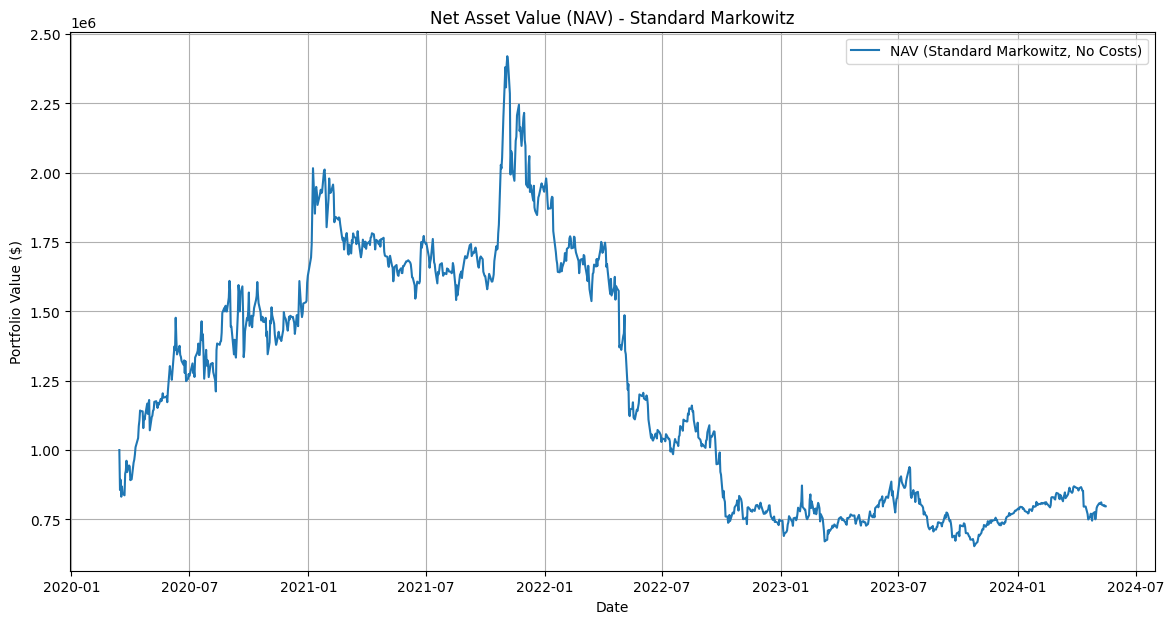

In [9]:
# (b) Run standard Markowitz backtest (ignoring TC for NAV calculation)
# portfolio_matrix_b is W_c because the weights are the same as in (c)
print("--- Part (b): Standard Markowitz Strategy (Weights) ---")
print("Portfolio Weight Matrix W:")
print(W_c_df.to_string(float_format="%.4f"))

# Plot
plt.figure(figsize=(14, 7))
plt.plot(nav_no_tc, label='NAV (Standard Markowitz, No Costs)')
plt.title('Net Asset Value (NAV) - Standard Markowitz')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True)
plt.legend()
# The plot for (b) will be created and overlaid in the next steps.# (e) Calculate and print performance metrics
metrics_c = calculate_metrics(nav_with_tc, RISK_FREE_RATE)
metrics_d = calculate_metrics(nav_tc_opt, RISK_FREE_RATE)

print("\n--- Part (e): Performance Metrics (with Transaction Costs) ---")
print("\nStandard Markowitz Strategy (from c):")
print(f"  Annualized Return:    {metrics_c[0]:.2%}")
print(f"  Annualized Sharpe:    {metrics_c[1]:.2f}")
print(f"  Max Drawdown:         {metrics_c[2]:.2%}")

print("\nTurnover-Aware Strategy (from d):")
print(f"  Annualized Return:    {metrics_d[0]:.2%}")
print(f"  Annualized Sharpe:    {metrics_d[1]:.2f}")
print(f"  Max Drawdown:         {metrics_d[2]:.2%}")




--- Part (c): Standard Markowitz with Transaction Costs ---
Total Transaction Costs: $239,420.92


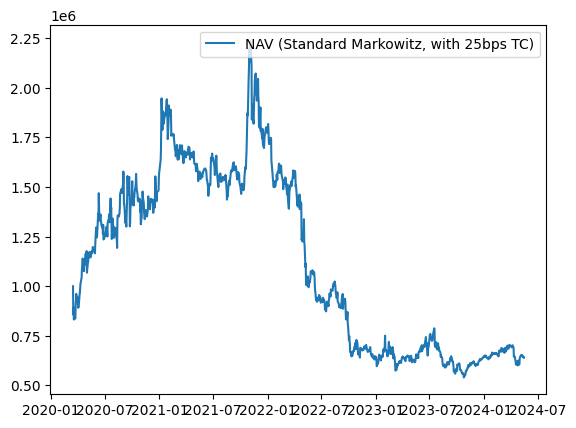

In [10]:
# (c) Calculate TC for standard strategy and overlay NAV
print("\n--- Part (c): Standard Markowitz with Transaction Costs ---")
print(f"Total Transaction Costs: ${total_tc_c:,.2f}")

# Overlay plot
plt.plot(nav_with_tc, label='NAV (Standard Markowitz, with 25bps TC)')
plt.legend()
# The plot will be displayed after part (d).



--- Part (d): Turnover-Aware Markowitz Strategy ---
New Portfolio Weight Matrix W (Turnover-Aware):
      Rebal_0  Rebal_1  Rebal_2  Rebal_3  Rebal_4  Rebal_5  Rebal_6  Rebal_7  Rebal_8  Rebal_9  Rebal_10  Rebal_11  Rebal_12  Rebal_13  Rebal_14  Rebal_15  Rebal_16  Rebal_17  Rebal_18  Rebal_19  Rebal_20  Rebal_21  Rebal_22  Rebal_23  Rebal_24  Rebal_25  Rebal_26  Rebal_27  Rebal_28  Rebal_29  Rebal_30  Rebal_31  Rebal_32  Rebal_33  Rebal_34  Rebal_35  Rebal_36  Rebal_37  Rebal_38  Rebal_39  Rebal_40  Rebal_41  Rebal_42  Rebal_43  Rebal_44  Rebal_45  Rebal_46  Rebal_47  Rebal_48  Rebal_49  Rebal_50
AAPL   0.2000   0.1999   0.2000   0.1999   0.1999   0.2000   0.2000   0.2000   0.1999   0.1999    0.1998    0.1998    0.1998    0.1998    0.1998    0.1998    0.1998    0.1998    0.1998    0.1997    0.1997    0.1999    0.1998    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1999    0.1998    0.1999    0.1999    0.1999    0.1998

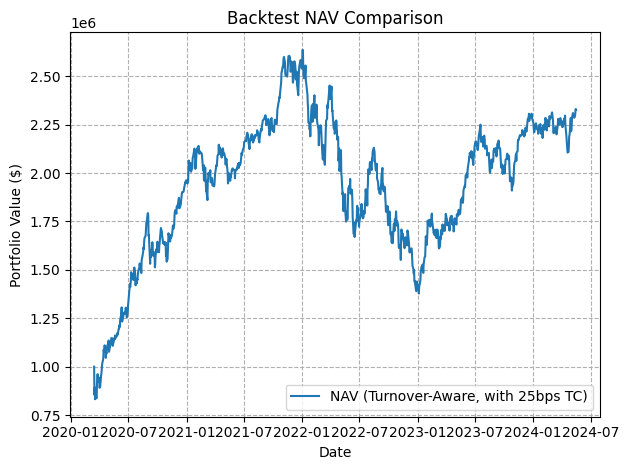

In [11]:
# (d) Run TC-optimized strategy, print results, and overlay NAV
print("\n--- Part (d): Turnover-Aware Markowitz Strategy ---")
print("New Portfolio Weight Matrix W (Turnover-Aware):")
print(W_d_df.to_string(float_format="%.4f"))
print(f"\nTotal Transaction Costs (Turnover-Aware): ${total_tc_d:,.2f}")
print(f"Comparison: The new costs (${total_tc_d:,.2f}) are significantly lower than the standard strategy's costs (${total_tc_c:,.2f}).")

# Overlay plot
plt.plot(nav_tc_opt, label='NAV (Turnover-Aware, with 25bps TC)')

# Finalize and show plot for (b), (c), and (d)
plt.title('Backtest NAV Comparison')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# (e) Calculate and print performance metrics
metrics_c = calculate_metrics(nav_with_tc, RISK_FREE_RATE)
metrics_d = calculate_metrics(nav_tc_opt, RISK_FREE_RATE)

print("\n--- Part (e): Performance Metrics (with Transaction Costs) ---")
print("\nStandard Markowitz Strategy (from c):")
print(f"  Annualized Return:    {metrics_c[0]:.2%}")
print(f"  Annualized Sharpe:    {metrics_c[1]:.2f}")
print(f"  Max Drawdown:         {metrics_c[2]:.2%}")

print("\nTurnover-Aware Strategy (from d):")
print(f"  Annualized Return:    {metrics_d[0]:.2%}")
print(f"  Annualized Sharpe:    {metrics_d[1]:.2f}")
print(f"  Max Drawdown:         {metrics_d[2]:.2%}")



--- Part (e): Performance Metrics (with Transaction Costs) ---

Standard Markowitz Strategy (from c):
  Annualized Return:    -10.17%
  Annualized Sharpe:    -0.29
  Max Drawdown:         75.81%

Turnover-Aware Strategy (from d):
  Annualized Return:    22.44%
  Annualized Sharpe:    0.70
  Max Drawdown:         47.74%
